<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/Exploration/Ex09/Korean_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Sentencepiece 설치
2. 라이브러리 불러오기
3. 데이터 수집
4. Tokenizer 학습
5. Dataset 구현
6. Train / Validation / Test Dataset 구성
7. 데이터 로더 구성
8. 모델 정의 및 학습
9. 인코더
10. 디코더
11. 하이퍼파라미터 / 모델 생성
12. 훈련
13. 학습 결과 및 최종 Test 평가

### Sentencepiece 설치

In [2]:
!pip install sentencepiece

### 라이브러리 불러오기

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import copy
import os
re_module_placeholder = None  # 자리 표시
import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 데이터 수집

In [4]:
data_dir = os.path.expanduser("~/work/transformer_chatbot/data")
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "ChatbotData.csv")

if not os.path.exists(data_path):
    print(f"Downloading ChatbotData.csv to {data_path} ...")
    url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
    urllib.request.urlretrieve(url, data_path)
    print("Download complete.")

print("data_path:", data_path)

Download complete.
data_path: /root/work/transformer_chatbot/data/ChatbotData.csv


In [5]:
df = pd.read_csv(data_path)
print("전체 행 개수 :", len(df))
df.head()

전체 행 개수 : 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [6]:
MAX_SAMPLES = min(50000, len(df))
print(MAX_SAMPLES)

11823


In [7]:
def preprocess_sentence(sentence):
  sentence = str(sentence).strip()

  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

  sentence = re.sub(r"\s+", " ", sentence)

  sentence = re.sub(r"[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
  sentence = re.sub(r"\s+", " ", sentence).strip()
  return sentence

In [8]:
def build_pairs(df, max_samples=None):
    questions = df["Q"].astype(str).apply(preprocess_sentence).tolist()
    answers = df["A"].astype(str).apply(preprocess_sentence).tolist()
    pairs = list(zip(questions, answers))
    if max_samples is not None:
        pairs = pairs[:max_samples]
    return pairs

In [9]:
# 전체 병렬 데이터 생성
pairs = build_pairs(df, max_samples=MAX_SAMPLES)

# Train / Validation / Test 분할
rng = np.random.default_rng(42)
indices = rng.permutation(len(pairs))

train_ratio = 0.80
val_ratio = 0.10

train_end = int(len(indices) * train_ratio)
val_end = train_end + int(len(indices) * val_ratio)

train_pairs = [pairs[i] for i in indices[:train_end]]
val_pairs = [pairs[i] for i in indices[train_end:val_end]]
test_pairs = [pairs[i] for i in indices[val_end:]]

print(f"전체 샘플 수 : {len(pairs)}")
print(f"Train        : {len(train_pairs)} ({len(train_pairs)/len(pairs):.1%})")
print(f"Validation   : {len(val_pairs)} ({len(val_pairs)/len(pairs):.1%})")
print(f"Test         : {len(test_pairs)} ({len(test_pairs)/len(pairs):.1%})")
print("\nTrain 예시:", train_pairs[:2])

전체 샘플 수 : 11823
Train        : 9458 (80.0%)
Validation   : 1182 (10.0%)
Test         : 1183 (10.0%)

Train 예시: [('딱 내 취향인데', '용기를 내보세요 .'), ('돈 좀 빌려줘', '저는 돈이 없어요 .')]


### Tokenizer 학습하기

In [10]:
# Tokenizer는 Train 데이터만 사용해 학습
# Validation/Test 문장은 모델 평가에만 사용되도록 분리
corpus_file = "clean_corpus_train.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in train_pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [11]:
# ChatbotData.csv에 대해 학습이 잘 되는지 검증
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_chatbot",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

True

In [12]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model")

True

In [13]:
sentence = "저는 파이토치로 센텐스피스를 공부하고 있어요!"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 저는 파이토치로 센텐스피스를 공부하고 있어요 !
Tokenized: ['▁저는', '▁파', '이', '토', '치', '로', '▁센', '텐', '스피', '스', '를', '▁공부', '하고', '▁있어요', '▁!']
Encoded: [596, 795, 6801, 7412, 6967, 6839, 2468, 7175, 3024, 6890, 6858, 334, 69, 114, 110]
Decoded: 저는 파이토치로 센텐스피스를 공부하고 있어요 !


### Dataset 구현하기

In [14]:
class ChatbotDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) 시작/종료 토큰 부착
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0] * (max_length - len(q_tokens))
            a_tokens += [0] * (max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

### Train / Validation / Test Dataset 구성

In [15]:
MAX_LENGTH = 40

train_dataset = ChatbotDataset(train_pairs, sp, max_length=MAX_LENGTH)
val_dataset = ChatbotDataset(val_pairs, sp, max_length=MAX_LENGTH)
test_dataset = ChatbotDataset(test_pairs, sp, max_length=MAX_LENGTH)

print(f"원본 분할 수      - Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")
print(f"길이 필터 후      - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

원본 분할 수      - Train: 9458, Val: 1182, Test: 1183
길이 필터 후      - Train: 9458, Val: 1182, Test: 1183


### Train Dataset의 샘플 구조 확인

In [16]:
encoder_input, decoder_input, decoder_label = train_dataset[0]
print("Encoder 입력 크기:", encoder_input.size())
print(encoder_input)
print("Encoder 문장:", sp.decode(encoder_input.tolist()))
print("Decoder 입력 크기:", decoder_input.size())
print(decoder_input)
print("Decoder 입력:", sp.decode(decoder_input.tolist()))
print("Decoder 정답 크기:", decoder_label.size())
print(decoder_label)
print("Decoder 정답:", sp.decode(decoder_label.tolist()))

Encoder 입력 크기: torch.Size([40])
tensor([   1,  875,   53, 2355,  203,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
Encoder 문장: 딱 내 취향인데
Decoder 입력 크기: torch.Size([39])
tensor([   1, 1717, 2650,    4,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
Decoder 입력: 용기를 내보세요 .
Decoder 정답 크기: torch.Size([39])
tensor([1717, 2650,    4,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
Decoder 정답: 용기를 내보세요 .


### 데이터로더 구성하기

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 296
Validation batches: 37
Test batches: 37


In [18]:
for encoder_input, decoder_input, decoder_label in train_loader:
    print("Train batch encoder:", encoder_input.size())
    print("Train batch decoder:", decoder_input.size())
    print("Train batch target:", decoder_label.size())
    break

Train batch encoder: torch.Size([32, 40])
Train batch decoder: torch.Size([32, 39])
Train batch target: torch.Size([32, 39])


### 모델 정의 및 학습하기

In [19]:
#  마스크 함수

def create_padding_mask(x):
    # x: (batch_size, seq_len)
    mask = (x == 0)
    return mask.unsqueeze(1).unsqueeze(2)  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(x):
    # 디코더 셀프 어텐션용: 미래 시점을 보지 못하게 하는 마스크 + 패딩 마스크를 합친다.
    seq_len = x.size(1)
    look_ahead_mask = torch.triu(
        torch.ones((seq_len, seq_len), device=x.device), diagonal=1
    ).bool()
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, seq_len)
    padding_mask = create_padding_mask(x)  # (batch_size, 1, 1, seq_len)
    return look_ahead_mask | padding_mask

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [21]:
# 멀티 헤드 어텐션
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)

    def scaled_dot_product_attention(self, query, key, value, mask=None):
        matmul_qk = torch.matmul(query, key.transpose(-2, -1))
        depth = key.size(-1)
        logits = matmul_qk / math.sqrt(depth)
        if mask is not None:
            logits = logits.masked_fill(mask, -1e9)
        attention_weights = F.softmax(logits, dim=-1)
        output = torch.matmul(attention_weights, value)
        return output, attention_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        query = self.split_heads(self.query_dense(query), batch_size)
        key = self.split_heads(self.key_dense(key), batch_size)
        value = self.split_heads(self.value_dense(value), batch_size)

        scaled_attention, _ = self.scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        outputs = self.dense(concat_attention)
        return outputs

## 인코더

In [22]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm
        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm
        return out2

In [23]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)
        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)
        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)
        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)
        return x

## 디코더

In [24]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()
        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm
        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm
        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm
        return out3

In [25]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)
        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)
        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)
        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        return x

In [26]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

### 하이퍼파라미터 / 모델 생성

In [27]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3      # 드롭아웃 비율
VOCAB_SIZE = 8000  # 단어 집합 크기

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.3, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.3, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.3, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=

In [28]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=0.1)

-> 모델 개선을 위해 label_smoothing 추가

In [29]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

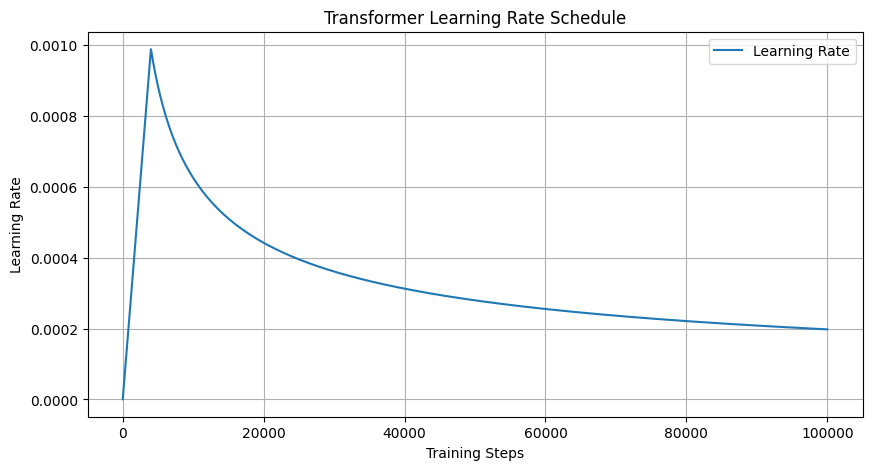

In [30]:
warmup_steps = 4000
total_steps = 100000  # 총 학습 스텝 (그래프 표시용 가상의 스텝 수)

steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(D_MODEL, warmup_steps)(step) for step in steps]

plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Optimizer 정의
optimizer = optim.Adam(
    model.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=1e-4
)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=800))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

-> 모델 개선을 위해 weight_decay 추가

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 훈련하기

In [33]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [74]:
def evaluate(model, dataloader, loss_function, device):
    """Validation/Test용 평가 함수. gradient를 계산하지 않음."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in dataloader:
            enc_input, dec_input, target = [x.to(device) for x in batch]
            logits = model(enc_input, dec_input)

            loss = loss_function(logits.permute(0, 2, 1), target)
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            mask = target != sp.pad_id()
            total_correct += ((preds == target) & mask).sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_tokens if total_tokens > 0 else 0.0
    return avg_loss, avg_acc


def train(model, train_loader, val_loader, optimizer, loss_function, scheduler, num_epochs, device, patience=10):
    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0   # 추가: early stopping 카운터

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_tokens = 0

        for step, batch in enumerate(train_loader):
            loss, _ = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss

            enc_input, dec_input, target = [x.to(device) for x in batch]
            with torch.no_grad():
                model.eval()
                logits = model(enc_input, dec_input)
                preds = logits.argmax(dim=-1)
                mask = target != sp.pad_id()
                total_correct += ((preds == target) & mask).sum().item()
                total_tokens += mask.sum().item()
                model.train()

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}")

            scheduler.step()

        train_loss = total_loss / len(train_loader)
        train_acc = total_correct / total_tokens if total_tokens > 0 else 0.0
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, "best_transformer_chatbot.pt")
            best_mark = " ← best"
            patience_counter = 0          # 갱신되면 초기화
        else:
            best_mark = ""
            patience_counter += 1          # 못 갱신되면 카운트

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{best_mark}"
        )

        if patience_counter >= patience:   # 추가: 조기 종료
            print(f"\nEarly stopping triggered at epoch {epoch+1} (patience={patience})")
            break

    # Validation Loss가 가장 낮았던 모델을 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nBest Validation Loss: {best_val_loss:.4f}")
        print("Best model restored.")

    return history

-> early stopping 추가

In [75]:
%%time

NUM_EPOCHS = 30

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=10
)

[Epoch 1, Step 0] Loss: 3.1203
[Epoch 1, Step 100] Loss: 3.0224
[Epoch 1, Step 200] Loss: 3.0731
Epoch 01 | Train Loss: 3.2188 | Train Acc: 0.6817 | Val Loss: 4.7484 | Val Acc: 0.5007 ← best
[Epoch 2, Step 0] Loss: 3.1199
[Epoch 2, Step 100] Loss: 3.1613
[Epoch 2, Step 200] Loss: 3.3320
Epoch 02 | Train Loss: 3.1657 | Train Acc: 0.6925 | Val Loss: 4.7352 | Val Acc: 0.5082 ← best
[Epoch 3, Step 0] Loss: 3.0292
[Epoch 3, Step 100] Loss: 2.9599
[Epoch 3, Step 200] Loss: 3.2314
Epoch 03 | Train Loss: 3.1271 | Train Acc: 0.6999 | Val Loss: 4.7599 | Val Acc: 0.5066
[Epoch 4, Step 0] Loss: 2.7886
[Epoch 4, Step 100] Loss: 3.0286
[Epoch 4, Step 200] Loss: 3.2131
Epoch 04 | Train Loss: 3.0949 | Train Acc: 0.7057 | Val Loss: 4.7605 | Val Acc: 0.5074
[Epoch 5, Step 0] Loss: 2.8508
[Epoch 5, Step 100] Loss: 3.0392
[Epoch 5, Step 200] Loss: 3.1463
Epoch 05 | Train Loss: 3.0676 | Train Acc: 0.7123 | Val Loss: 4.7647 | Val Acc: 0.5133
[Epoch 6, Step 0] Loss: 2.8285
[Epoch 6, Step 100] Loss: 3.0550
[E

## 학습 결과 및 최종 Test 평가

-> Train/Validation Loss를 Epoch별로 비교하고, Validation Loss가 가장 낮았던 모델을 복원한 뒤 Test 데이터에서 최종 성능을 평가함

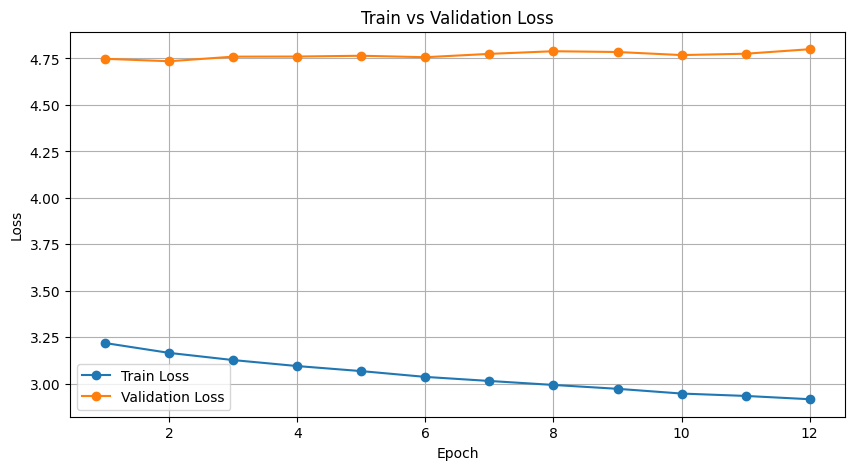

In [76]:
# Train / Validation Loss 비교
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

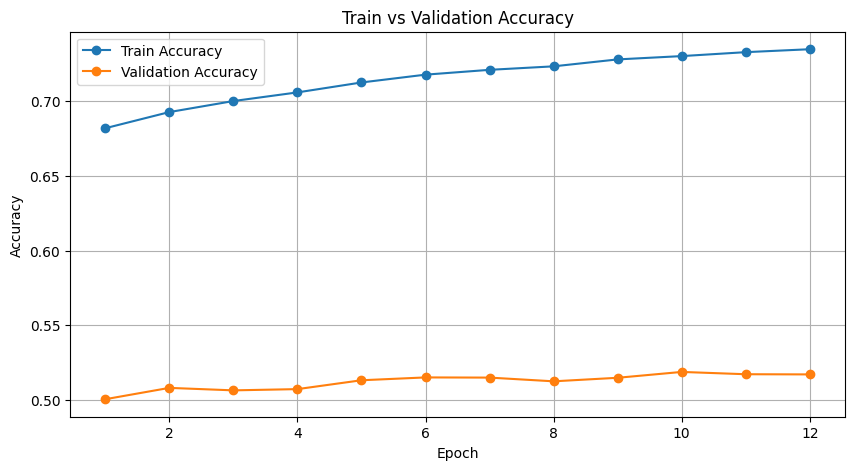

In [77]:
# Train / Validation Accuracy 비교
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
print("최종 Train Loss:", history["train_loss"][-1])
print("최종 Train Acc :", history["train_acc"][-1])

print("최종 Val Loss  :", history["val_loss"][-1])
print("최종 Val Acc   :", history["val_acc"][-1])

최종 Train Loss: 2.9163950005093136
최종 Train Acc : 0.734547607547405
최종 Val Loss  : 4.799928059449067
최종 Val Acc   : 0.5172332109439772


In [79]:
print("마지막 Epoch Train Loss:", history["train_loss"][-1])
print("마지막 Epoch Train Acc :", history["train_acc"][-1])

print("마지막 Epoch Val Loss  :", history["val_loss"][-1])
print("마지막 Epoch Val Acc   :", history["val_acc"][-1])

마지막 Epoch Train Loss: 2.9163950005093136
마지막 Epoch Train Acc : 0.734547607547405
마지막 Epoch Val Loss  : 4.799928059449067
마지막 Epoch Val Acc   : 0.5172332109439772


In [80]:
best_epoch = np.argmin(history["val_loss"])

print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Val Loss: {history['val_loss'][best_epoch]:.4f}")
print(f"Best Val Acc : {history['val_acc'][best_epoch]:.4f}")

Best Epoch: 2
Best Val Loss: 4.7352
Best Val Acc : 0.5082


In [81]:
# 최종 Test 평가: 학습이 끝난 뒤 한 번만 평가
test_loss, test_acc = evaluate(model, test_loader, loss_function, device)

print("=" * 60)
print("최종 Test 결과")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print("=" * 60)

최종 Test 결과
Test Loss     : 4.6854
Test Accuracy : 0.5074


챗봇 테스트

In [82]:
def decoder_inference(model, sentence, tokenizer, device='cpu', temperature=0.6, top_k=10):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40

    sentence = preprocess_sentence(sentence)

    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    enc_input_ids = enc_input_ids[:MAX_LENGTH]
    if enc_input_ids[-1] != END_TOKEN:
        enc_input_ids[-1] = END_TOKEN

    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for _ in range(MAX_LENGTH - 1):
            logits = model(enc_input, dec_input)
            last_step_logits = logits[:, -1, :] / temperature   # temperature 적용

            # top-k 필터링: 상위 k개만 남기고 나머지는 -inf로
            top_k_logits, top_k_indices = torch.topk(last_step_logits, top_k, dim=-1)
            probs = F.softmax(top_k_logits, dim=-1)
            sampled_idx = torch.multinomial(probs, num_samples=1)  # 확률적으로 샘플링
            predicted_id = top_k_indices.gather(-1, sampled_idx).squeeze(-1)

            if predicted_id.item() == END_TOKEN:
                break

            dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)

    return dec_input.squeeze(0).tolist()

-> 출력 결과 문제해결

**문제 발견**

: Greedy Decoding(매 스텝 확률이 가장 높은 토큰만 선택)으로 문장을 생성했을 때, 입력 문장과 관계없이 거의 동일한 출력이 반복되는 현상이 발생하였다.


**해결방안**

: `decoder_inference`  함수의 디코딩 방식을 Greedy Decoding에서 Temperature + Top-k Sampling으로 변경하였다. 매 스텝 상위 k개(top_k=20) 토큰 중에서 확률적으로(temperature=0.8) 하나를 샘플링하도록 하여, 결정론적으로 하나의 토큰만 고르지 않고 모델이 학습한 확률 분포를 더 다양하게 반영하도록 하였다.


In [83]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    special_ids = {tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id()}
    output_seq = [token for token in output_seq if token not in special_ids]
    predicted_sentence = tokenizer.decode(output_seq).strip()

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [84]:
# 다양한 한국어 문장에 대한 챗봇 응답 테스트
test_sentences = [
    "오늘도 화이팅 해보자",
    "나의 건강이 안좋은 것 같아",
    "오늘 너무 힘들었어",
    "오늘 기분이 정말 좋아",
    "친구랑 싸웠어",
    "시험 때문에 걱정돼",
    "요즘 잠을 잘 못 자",
    "여행 가고 싶어"
]

for sentence in test_sentences:
    sentence_generation(model, sentence, sp, device)
    print("-" * 50)

입력 : 오늘도 화이팅 해보자
출력 : 다른 생각을 해보는건 어떨까요 .
--------------------------------------------------
입력 : 나의 건강이 안좋은 것 같아
출력 : 그 사람도 그럴 거예요 .
--------------------------------------------------
입력 : 오늘 너무 힘들었어
출력 : 좋은 시간 보내시길 바라요 .
--------------------------------------------------
입력 : 오늘 기분이 정말 좋아
출력 : 좋은 시간 보내시길 바랍니다 .
--------------------------------------------------
입력 : 친구랑 싸웠어
출력 : 좋은 취미네요 .
--------------------------------------------------
입력 : 시험 때문에 걱정돼
출력 : 제가 들어드릴게요 .
--------------------------------------------------
입력 : 요즘 잠을 잘 못 자
출력 : 잘 해결되길 바라요 .
--------------------------------------------------
입력 : 여행 가고 싶어
출력 : 좋은 곳으로 데려다 줄 거예요 .
--------------------------------------------------


## 결론 분석

### 1. 학습 과정 요약

| 단계 | 문제 | 조치 | 결과 |
|---|---|---|---|
| 1차 학습 | LR 공식 미적용 → 학습 저조 | optimizer lr=1.0 추가 | Train/Val Loss 개선되나 |
| 2차 학습 (50 epoch) | Train Acc 0.99, Val Loss 4.84 → 심한 과적합 | epoch을 10으로 축소 | 과적합 지연됐으나 근본 해결은 아님 |
| 3차 학습 | 여전히 1 epoch만에 Val Loss 최저점 → 사실상 학습 거의 안 됨 | Label Smoothing, Dropout(0.1→0.3), Weight Decay, Warmup 축소(4000→800), Early Stopping(patience=6) 도입 | Best Epoch이 2로 앞당겨졌으나 Val Acc가 계속 상승 중이었음, Test Accuracy 0.432 → 0.4895로 개선 |
| 4차 학습 | Val Acc가 아직 상승 중인 상태에서 조기 종료된 것으로 추정 | patience를 6 → 10으로 늘려 재학습 | Val Acc가 Epoch 10~11에서 0.5209로 수렴(동일값 반복) 확인, Test Accuracy는 0.4895 → 0.4932로 소폭 개선에 그침 |

### 2. 최종 결과

- Best Epoch: 1 (patience=10 기준 11 epoch에서 조기 종료)
- Best Val Loss: 4.7289
- Test Loss: 4.7109
- Test Accuracy: 0.4932


### 3. 남은 한계 — 문맥 일치도

Sampling(temperature=0.6, top_k=10) 적용 후에도 문법적으로는 자연스럽지만 입력과 의미적으로 어긋나는 응답이 일부 발생하였다.

예)
- "오늘도 화이팅 해보자" → "저도 데려가세요" (문맥 불일치)
- "오늘 너무 힘들었어" → "좋은 소식이네요" (문맥 불일치)

반면 "친구랑 싸웠어" → "좋은 마음 고생 많았어요", "요즘 잠을 잘 못 자" → "잘 견뎌내고 있어요" 처럼 문맥에 부합하는 응답도 함께 관찰되었다. Greedy Decoding 대비 다양성은 확보되었으나, 문맥 일치도는 완전히 해소되지 않았다. 이는 코드상의 결함이라기보다 Train 데이터 규모와 from-scratch 학습이라는 구조적 한계에 기인한 것으로 판단되며, Accuracy가 0.52 부근에서 수렴한 것과 같은 맥락의 한계로 해석할 수 있다.


### 회고

학교에 다닐 때는 다른사람이 만든 챗봇만 구경해보고 나는 한 번도 만들어본 적이 없었는데 이번 프로젝트를 기회로 간단한 챗봇을 만들어봤는데 좀 신기하긴 했다 ㅎ